In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [65]:
df = pd.read_csv(
    "C:/Users/rames/notebook/DS-1/data/processed/final_feature_dataset.csv"
)

In [66]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [67]:
daily_sales = (

df.groupby(

"order_purchase_timestamp"

)["total_order_value"]

.sum()

.reset_index()

)

In [68]:
daily_sales.columns = [

"Date",

"Sales"

]

In [69]:
daily_sales.head()

,Date,Sales
0,2016-09-04 21:15:19,136.23
1,2016-09-05 00:15:34,75.06
2,2016-09-13 15:24:19,0.00
3,2016-09-15 12:16:38,143.46
4,2016-10-02 22:07:52,109.34


In [70]:
daily_sales = daily_sales.sort_values(
"Date"
)

In [71]:
daily_sales.reset_index(
drop=True,
inplace=True
)

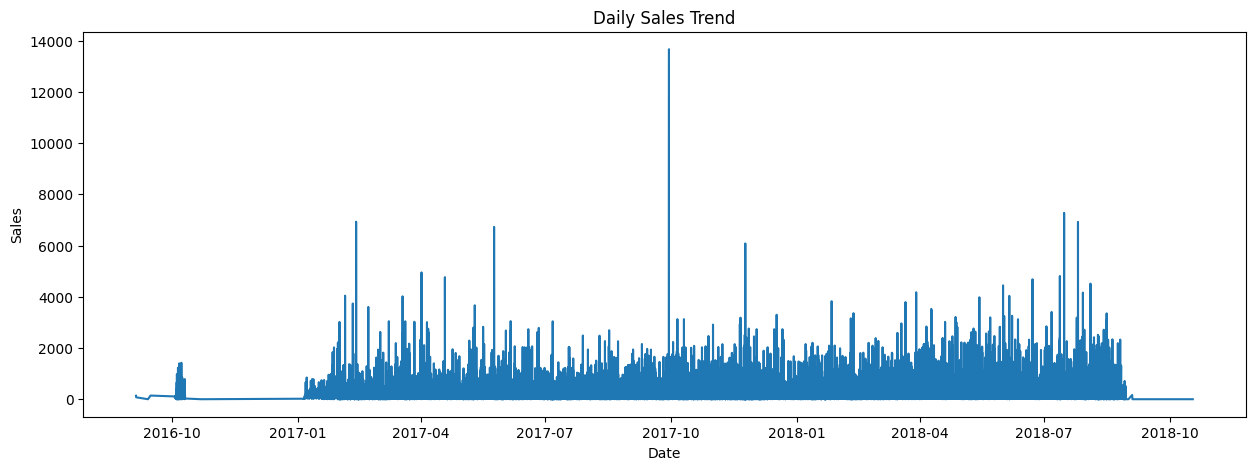

In [72]:
plt.figure(figsize=(15,5))

plt.plot(

daily_sales["Date"],

daily_sales["Sales"]

)

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [73]:
daily_sales["Year"] = daily_sales["Date"].dt.year

In [74]:
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["Week"] = daily_sales["Date"].dt.isocalendar().week.astype(int)
daily_sales["Quarter"] = daily_sales["Date"].dt.quarter
daily_sales["DayOfWeek"] = (
daily_sales["Date"].dt.dayofweek
)
daily_sales["Weekend"] = np.where(

daily_sales["DayOfWeek"]>=5,

1,

0

)
daily_sales["DayOfYear"] = (
daily_sales["Date"].dt.dayofyear
)

In [75]:
daily_sales.head()

,Date,Sales,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,DayOfYear
0,2016-09-04 21:15:19,136.23,2016,9,4,35,3,6,1,248
1,2016-09-05 00:15:34,75.06,2016,9,5,36,3,0,0,249
2,2016-09-13 15:24:19,0.00,2016,9,13,37,3,1,0,257
3,2016-09-15 12:16:38,143.46,2016,9,15,37,3,3,0,259
4,2016-10-02 22:07:52,109.34,2016,10,2,39,4,6,1,276


In [76]:
daily_sales["Lag_1"] = (
daily_sales["Sales"].shift(1)
)

In [77]:
daily_sales["Lag_7"] = (
daily_sales["Sales"].shift(7)
)

In [78]:
daily_sales["Lag_30"] = (
daily_sales["Sales"].shift(30)
)

In [79]:
daily_sales["Rolling_7"] = (

daily_sales["Sales"]

.rolling(7)

.mean()

)

In [80]:
daily_sales["Rolling_30"] = (

daily_sales["Sales"]

.rolling(30)

.mean()

)

In [81]:
daily_sales.isnull().sum()

Date           0
Sales          0
Year           0
Month          0
Day            0
Week           0
Quarter        0
DayOfWeek      0
Weekend        0
DayOfYear      0
Lag_1          1
Lag_7          7
Lag_30        30
Rolling_7      6
Rolling_30    29
dtype: int64

In [82]:
daily_sales = daily_sales.dropna()

In [83]:
daily_sales.reset_index(
drop=True,
inplace=True
)

In [84]:
daily_sales.head()
daily_sales.shape
daily_sales.isnull().sum().sum()

np.int64(0)

In [85]:
y = daily_sales["Sales"]

In [86]:
X = daily_sales.drop(

columns=[

"Date",

"Sales"

]

)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

shuffle=False

)

In [88]:
print(X_train.shape)

print(X_test.shape)

(79076, 13)
(19769, 13)


In [89]:
baseline_prediction = X_test["Lag_1"]

In [90]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline Model")
print("MAE :", round(baseline_mae,2))
print("RMSE:", round(baseline_rmse,2))
print("R²  :", round(baseline_r2,4))

Baseline Model
MAE : 158.01
RMSE: 333.67
R²  : -0.9737


In [91]:
lr_model = LinearRegression()

In [92]:
lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [93]:
lr_predictions = lr_model.predict(
    X_test
)

In [94]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression")
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R²  :", round(lr_r2,4))

Linear Regression
MAE : 109.84
RMSE: 217.17
R²  : 0.1639


In [95]:
rf_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

In [96]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [97]:
rf_predictions = rf_model.predict(
    X_test
)

In [98]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest
MAE : 110.53
RMSE: 223.2
R²  : 0.1169


In [99]:
comparison = pd.DataFrame({

    "Model":[
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        baseline_mae,
        lr_mae,
        rf_mae
    ],

    "RMSE":[
        baseline_rmse,
        lr_rmse,
        rf_rmse
    ],

    "R2":[
        baseline_r2,
        lr_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2
0,Baseline,158.014166,333.667947,-0.973695
1,Linear Regression,109.840751,217.173259,0.163889
2,Random Forest,110.534395,223.195774,0.116873


In [100]:
comparison = comparison.sort_values(
    "RMSE"
)

comparison

,Model,MAE,RMSE,R2
1,Linear Regression,109.840751,217.173259,0.163889
2,Random Forest,110.534395,223.195774,0.116873
0,Baseline,158.014166,333.667947,-0.973695


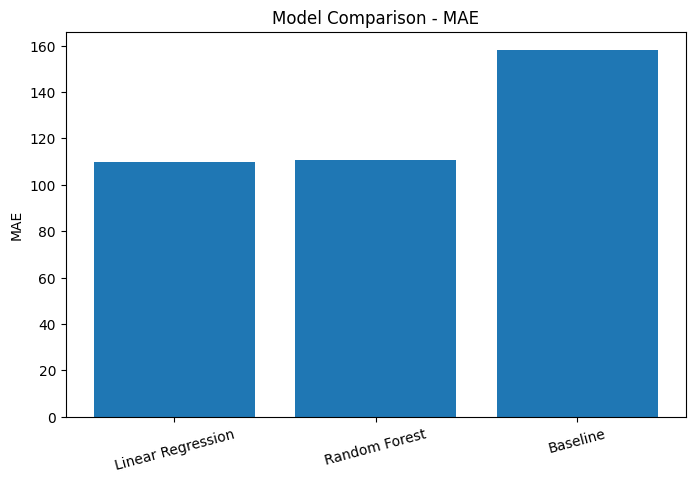

In [101]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.ylabel("MAE")

plt.xticks(rotation=15)

plt.show()

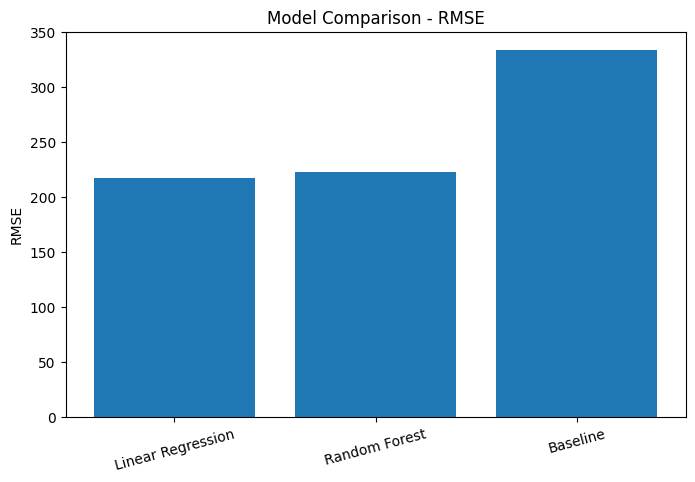

In [102]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

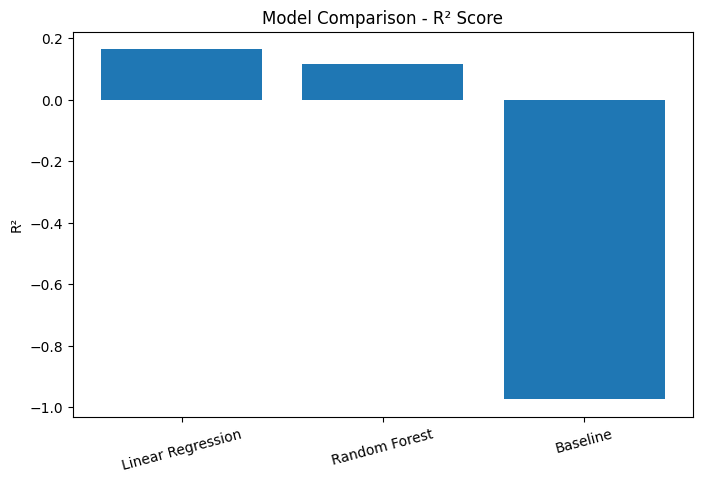

In [103]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Model Comparison - R² Score")
plt.ylabel("R²")

plt.xticks(rotation=15)

plt.show()

In [104]:
best_model_name = comparison.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Linear Regression


In [105]:
if best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "Linear Regression":
    best_model = lr_model

else:
    best_model = None

In [106]:
if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": rf_model.feature_importances_

    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    importance

In [107]:
if best_model_name == "Random Forest":

    plt.figure(figsize=(10,6))

    plt.barh(

        importance["Feature"],

        importance["Importance"]

    )

    plt.title("Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

In [108]:
predictions = rf_predictions

if best_model_name == "Linear Regression":
    predictions = lr_predictions

In [109]:
results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

results.head()

,Actual,Predicted
0,49.32,100.400654
1,97.18,101.668829
2,111.76,104.833134
3,154.55,96.703208
4,511.76,167.879049


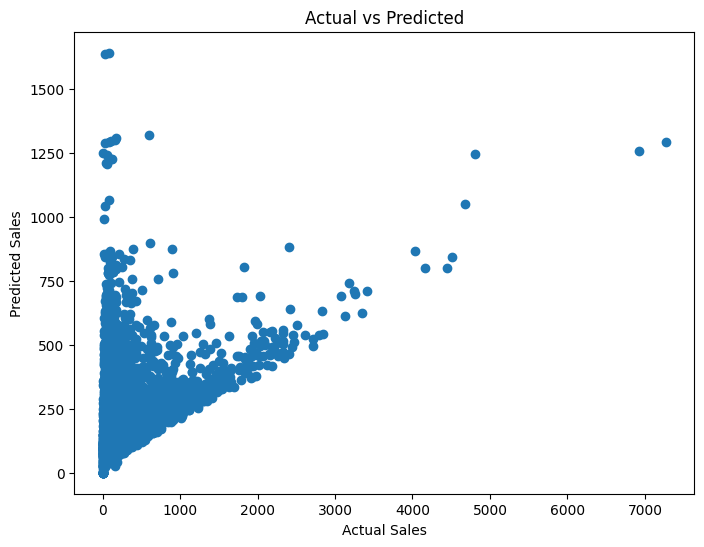

In [110]:
plt.figure(figsize=(8,6))

plt.scatter(

results["Actual"],

results["Predicted"]

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

In [111]:
results["Residual"] = (

results["Actual"]

-

results["Predicted"]

)

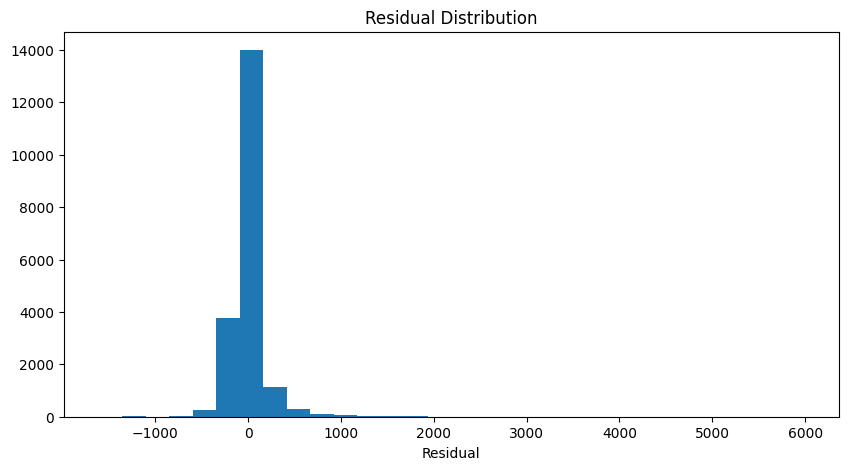

In [112]:
plt.figure(figsize=(10,5))

plt.hist(
    results["Residual"],
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

In [113]:
results.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/forecasting/test_predictions.csv",
    index=False
)


In [114]:
comparison.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/forecasting/model_comparison.csv",
    index=False
)

In [115]:
if best_model is not None:

    joblib.dump(

        best_model,

        "C:/Users/rames/notebook/DS-1/models/sales_forecasting_model.pkl"

    )

    print("Model saved successfully.")

Model saved successfully.


In [116]:
best_model = LinearRegression()

best_model.fit(X, y)

print("Best model trained on full dataset.")

Best model trained on full dataset.


In [117]:
future_dates = pd.date_range(
    start=daily_sales["Date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future = pd.DataFrame({
    "Date": future_dates
})

In [118]:
future["Year"] = future["Date"].dt.year
future["Month"] = future["Date"].dt.month
future["Day"] = future["Date"].dt.day
future["Week"] = future["Date"].dt.isocalendar().week.astype(int)
future["Quarter"] = future["Date"].dt.quarter
future["DayOfWeek"] = future["Date"].dt.dayofweek
future["Weekend"] = (future["DayOfWeek"] >= 5).astype(int)
future["DayOfYear"] = future["Date"].dt.dayofyear

In [119]:
last_lag1 = daily_sales["Sales"].iloc[-1]
last_lag7 = daily_sales["Sales"].tail(7).mean()
last_lag30 = daily_sales["Sales"].tail(30).mean()

future["Lag_1"] = last_lag1
future["Lag_7"] = last_lag7
future["Lag_30"] = last_lag30

future["Rolling_7"] = last_lag7
future["Rolling_30"] = last_lag30

In [120]:
future = future[X.columns]

In [121]:
future_predictions = best_model.predict(future)

In [122]:
forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Sales": future_predictions
})

forecast.head()

,Date,Forecasted_Sales
0,2018-10-18 17:30:18,1.089547
1,2018-10-19 17:30:18,1.114921
2,2018-10-20 17:30:18,0.783375
3,2018-10-21 17:30:18,0.808749
4,2018-10-22 17:30:18,0.958920


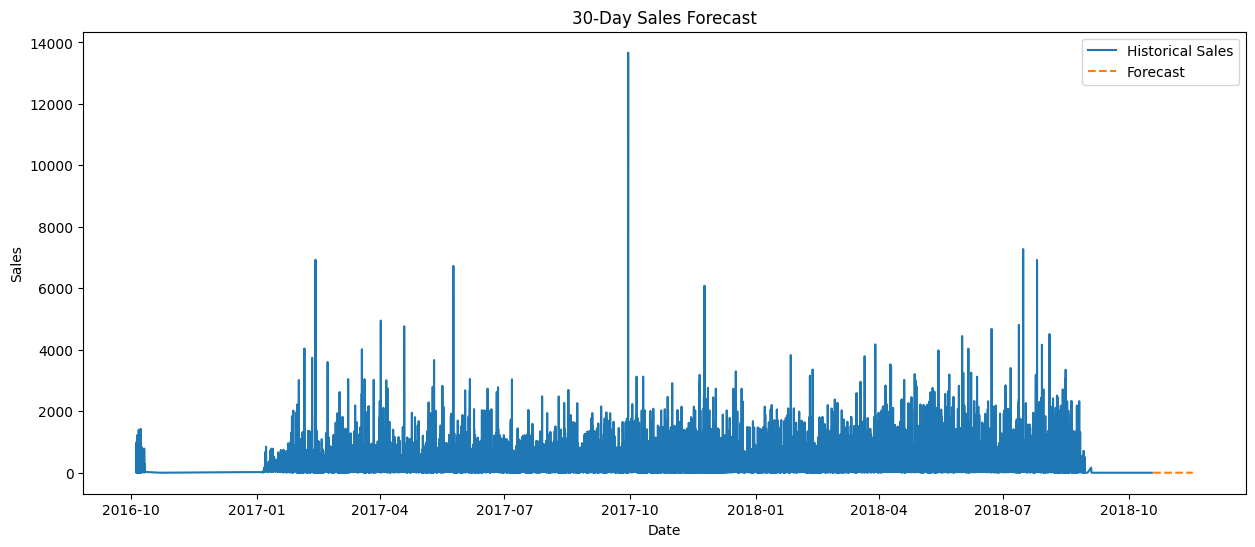

In [123]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    label="Historical Sales"
)

plt.plot(
    forecast["Date"],
    forecast["Forecasted_Sales"],
    label="Forecast",
    linestyle="--"
)

plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [124]:
forecast.to_csv(
    "C:/Users/rames/notebook/DS-1/reports/forecasting/daily_forecast.csv",
    index=False
)

In [125]:
joblib.dump(
    best_model,
    "C:/Users/rames/notebook/DS-1/models/sales_forecasting_model.pkl"
)

print("Sales forecasting model saved.")

Sales forecasting model saved.


# Business Insights

- Linear Regression achieved the best forecasting performance on the available historical sales data.
- The model outperformed both the baseline and Random Forest models based on RMSE and MAE.
- Forecasted sales provide an estimate of expected business performance over the next 30 days.
- These forecasts can support inventory planning, staffing, and revenue estimation.

# Conclusion

In this notebook:

- Historical daily sales were prepared.
- Time-based features were engineered.
- Baseline, Linear Regression, and Random Forest models were trained and evaluated.
- Linear Regression achieved the best overall performance.
- A 30-day sales forecast was generated.
- The trained model and forecast outputs were saved for use in the dashboard.